# WellClass: load, validate, and derive a well

This recipe is only about WellClass. It loads the typed Frigg example, keeps the raw input available, and derives well path, TVD intervals, borehole, cement bond, and annulus data.

In [5]:
from pathlib import Path
import pandas as pd
from src.WellClass.libs.well_class import Well, WellProcessed

root = Path.cwd()
if not (root / 'test_data').exists():
    root = root.parent
frigg_json = root / 'test_data/examples/frigg/frigg.json'

## Raw and processed representations

In [6]:
raw_well = Well.from_json(frigg_json)
processed_well = WellProcessed.from_json(frigg_json)

print(raw_well.inventory)
print(processed_well.inventory)
print(processed_well.header)

{'hole_casings': True, 'survey': True, 'plugs': True, 'stratigraphy': True}
{'hole_casings': True, 'survey': True, 'plugs': True, 'stratigraphy': True}
{'unique_wellbore_identifier': 'NO 25/1-10', 'depth_reference_rkb': 27.0, 'depth_reference_rkb_unit': 'm', 'ground_elevation': 99.0, 'ground_elevation_unit': 'm', 'total_depth_rkb': 4739.0, 'total_depth_rkb_unit': 'm'}


## Derived WellClass data

In [7]:
hole_casings = pd.DataFrame(processed_well.hole_casings)
borehole = pd.DataFrame(processed_well.borehole)
annulus = pd.DataFrame(processed_well.annulus)

display(hole_casings[['name', 'type', 'top_rkb', 'bottom_rkb', 'diameter_in']])
display(borehole[['top_rkb', 'bottom_rkb', 'top_tvd_msl', 'bottom_tvd_msl', 'diameter_m']])
display(annulus[['top_rkb', 'bottom_rkb', 'top_tvd_msl', 'bottom_tvd_msl', 'an_thickness_m']])

,name,type,top_rkb,bottom_rkb,diameter_in
0,Hole 36 in,hole,126.0,189.0,36.000
1,Hole 26 in,hole,189.0,923.0,26.000
2,Hole 17 1/2 in,hole,923.0,2839.0,17.500
3,Hole 12 1/4 in,hole,2839.0,4085.0,12.250
4,Hole 8 3/8 in,hole,4085.0,4470.0,8.375
5,Hole 5 7/8 in,hole,4470.0,4739.0,5.875
6,Casing 30 in,casing,126.0,188.0,30.000
7,Casing 20 in,casing,126.0,910.0,20.000
8,Casing 13 3/8 in,casing,693.0,2825.0,13.375
9,Casing 9 5/8 in,casing,785.0,4043.0,9.625


,top_rkb,bottom_rkb,top_tvd_msl,bottom_tvd_msl,diameter_m
0,126.0,693.0,98.998273,665.981527,0.508000
1,693.0,785.0,665.981527,757.955759,0.339725
2,785.0,3936.0,757.955759,3906.982380,0.244475
3,3936.0,4470.0,3906.982380,4436.829077,0.177800
4,4470.0,4739.0,4436.829077,4704.694542,0.149225


,top_rkb,bottom_rkb,top_tvd_msl,bottom_tvd_msl,an_thickness_m
0,126.0,188.0,98.99827266276596,160.99659919577508,0.076200
1,126.0,188.0,98.99827266276596,160.99659919577508,0.127000
2,188.0,189.0,160.99659919577508,161.9965799228727,0.203200
3,189.0,910.0,161.9965799228727,882.9431765909171,0.076200
4,693.0,910.0,665.9815272015866,882.9431765909171,0.084138
5,785.0,2825.0,757.9557593964954,2797.287090121351,0.047625
6,910.0,923.0,882.9431765909171,895.9427446136193,0.160337
7,923.0,2825.0,895.9427446136193,2797.287090121351,0.052388
8,2825.0,2839.0,2797.287090121351,2811.286861302984,0.100013
9,2839.0,4043.0,2811.286861302984,4012.7886710250723,0.033337


## Visual quality control

KeyError: 'tvd_msl_top'

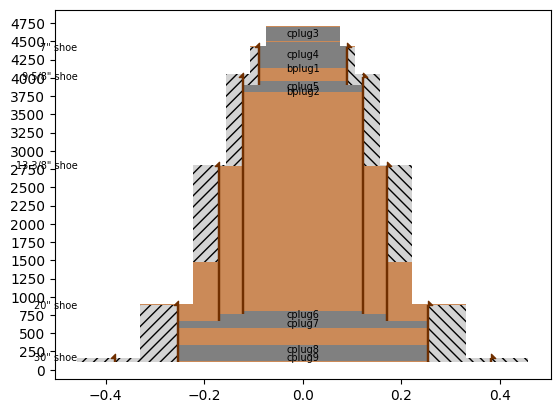

In [ ]:
import matplotlib.pyplot as plt
from src.WellClass.libs.plotting.plot_sketch import plot_sketch

fig, ax = plot_sketch(processed_well, draw_open_hole=False)
ax.set_title('WellClass derived well geometry')
fig.tight_layout()
plt.show()

In [ ]:
assert len(processed_well.borehole) > 0
assert len(processed_well.annulus) > 0
assert all(row['bottom_rkb'] >= row['top_rkb'] for row in processed_well.borehole)
print('WellClass derivation checks passed')

WellClass derivation checks passed
